# Bibliotecas

In [ ]:
# @title Importação
!python -m spacy download pt_core_news_sm
!pip install nltk

import xgboost as xgbaa
from sklearn.feature_extraction.text import TfidfVectorizer
from textblob import TextBlob

import polars as pl
import numpy as np
from nltk.stem import PorterStemmer
import nltk
import spacy
import re
from nltk.corpus import stopwords

from nltk.tokenize import word_tokenize
import string

import unicodedata
from collections import Counter
from math import log

nltk.download('stopwords')
nltk.download('punkt')


from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb

import matplotlib.pyplot as plt
import seaborn as sns

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 95.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# Funções

In [ ]:
class TextPreprocessor:
    def __init__(self,
                 remove_stopwords: bool = True,
                 stemming: bool = True,
                 lemmatization: bool = True,
                 lowercase: bool = True,
                 remove_special_chars: bool = True,
                 remove_short_words: bool = True,
                 keep_words_only: bool = True,
                 keep_top_n_words: int = 5000,
                 custom_stopwords: list[str] = None):  # Novo parâmetro
        self.remove_stopwords = remove_stopwords
        self.stemming = stemming
        self.lemmatization = lemmatization
        self.lowercase = lowercase
        self.remove_special_chars = remove_special_chars
        self.remove_short_words = remove_short_words
        self.keep_words_only = keep_words_only
        self.keep_top_n_words = keep_top_n_words
        self.stop_words = set(stopwords.words('portuguese'))
        self.stemmer = PorterStemmer()
        self.nlp = spacy.load("pt_core_news_sm")
        self.top_n_words = None

        # Adiciona stopwords personalizadas
        if custom_stopwords:
            self.stop_words.update(custom_stopwords)

    def preprocess_text(self, text: str) -> str:
        if self.lowercase:
            text = text.lower()

        if self.remove_special_chars:
            text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

        tokens = word_tokenize(text)

        if self.remove_stopwords:
            tokens = [word for word in tokens if word not in self.stop_words]

        if self.stemming:
            tokens = [self.stemmer.stem(word) for word in tokens]

        if self.lemmatization:
            doc = self.nlp(" ".join(tokens))
            tokens = [token.lemma_ for token in doc]

        if self.remove_short_words:
            tokens = [word for word in tokens if len(word) >= 3]

        if self.keep_words_only:
            tokens = [word for word in tokens if word.isalpha()]

        if self.top_n_words:
            tokens = [word for word in tokens if word in self.top_n_words]

        return tokens

    def fit_top_n_words(self, texts: list[str]):
        freq_dist = nltk.FreqDist(word for text in texts for word in word_tokenize(text))
        self.top_n_words = set(word for word, _ in freq_dist.most_common(self.keep_top_n_words))

    def transform(self, df: pl.DataFrame, text_column: str) -> pl.DataFrame:
        if self.keep_top_n_words:
            self.fit_top_n_words(df[text_column].to_list())

        df = df.with_columns(
            pl.col(text_column).apply(self.preprocess_text).alias(text_column + "_processed")
        )
        return df

custom_stopwords = ["pra", "todo", "algum", "bem","vez", "pouco", "todo", "grande", "nada",
                    "assistir", "saber", "ter", "tenho", "tem", "tudo", "consigo", "conseguir",
                    "posso", "poder", "outro", "ainda", "ver", "vi", "achei", "sei", "saber",
                    "muita", "muito", "quando","ator", "tanto", "demais"]


In [ ]:
# @title Vetorizações

def count_vectorizer(df: pl.DataFrame, text_column: str) -> pl.DataFrame:
    """
    Cria uma matriz de contagem de termos a partir de um DataFrame do Polars.

    Args:
        df: DataFrame do Polars contendo o texto pré-processado a ser vetorizado.
        text_column: Nome da coluna no DataFrame que contém o texto pré-processado.

    Returns:
        DataFrame do Polars com a matriz de contagem de termos.
    """
    # Extrai o vocabulário
    vocabulary = {token: idx for idx, token in enumerate(
        set(token for tokens in df[text_column] if tokens is not None for token in tokens)
    )}

    # Inicializa a matriz de contagem de termos com zeros
    term_matrix = np.zeros((len(df), len(vocabulary)))

    # Preenche a matriz com as contagens de termos
    for doc_idx, tokens in enumerate(df[text_column]):
        token_counts = Counter(tokens)
        for token, count in token_counts.items():
            if token in vocabulary:
                term_idx = vocabulary[token]
                term_matrix[doc_idx, term_idx] = count

    # Cria um DataFrame do Polars a partir da matriz de contagem de termos
    term_matrix_df = pl.DataFrame(term_matrix, schema=[f"term_{token}" for token in vocabulary])

    # Concatena o DataFrame original com o DataFrame da matriz de contagem de termos
    result_df = df.hstack(term_matrix_df)

    return result_df

def tfidf_vectorizer(df: pl.DataFrame, text_column: str) -> pl.DataFrame:
    """
    return result_df
    Cria uma matriz TF-IDF a partir de um DataFrame do Polars.

    Args:
        df: DataFrame do Polars contendo o texto pré-processado a ser vetorizado.
        text_column: Nome da coluna no DataFrame que contém o texto pré-processado.

    Returns:
        DataFrame do Polars com a matriz TF-IDF.
    """
    # Extrai o vocabulário
    vocabulary = {token: idx for idx, token in enumerate(
        set(token for tokens in df[text_column] for token in tokens)
    )}

    # Inicializa a matriz de contagem de termos com zeros
    term_matrix = np.zeros((len(df), len(vocabulary)))

    # Preenche a matriz com as contagens de termos
    for doc_idx, tokens in enumerate(df[text_column]):
        token_counts = Counter(tokens)
        for token, count in token_counts.items():
            if token in vocabulary:
                term_idx = vocabulary[token]
                term_matrix[doc_idx, term_idx] = count

    # Calcula o IDF
    doc_freq = np.sum(term_matrix > 0, axis=0)
    idf = np.log(len(df) / (doc_freq + 1))

    # Calcula o TF-IDF
    tfidf_matrix = term_matrix * idf

    # Normaliza as linhas da matriz TF-IDF
    row_norms = np.sqrt(np.sum(tfidf_matrix ** 2, axis=1, keepdims=True))
    tfidf_matrix = tfidf_matrix / row_norms

    # Cria um DataFrame do Polars a partir da matriz TF-IDF
    tfidf_matrix_df = pl.DataFrame(tfidf_matrix, schema=[f"tfidf_{token}" for token in vocabulary])

    # Concatena o DataFrame original com o DataFrame da matriz TF-IDF
    result_df = df.hstack(tfidf_matrix_df)

    return result_df


In [ ]:
# @title Avaliação do modelo
def evaluate_model(df, feature_pattern, target_column='polarity_label', test_size=0.2, random_state=42):
  # Seleciona as features usando o padrão regex
  X = df.select(pl.col(feature_pattern)).to_pandas()

  y = df.select(target_column).to_series()

  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=test_size, random_state=random_state
  )

  model = xgb.XGBClassifier()
  le = LabelEncoder()
  y_train_encoded = le.fit_transform(y_train)
  y_test_encoded = le.transform(y_test)
  model.fit(X_train, y_train_encoded)

  y_pred = model.predict(X_test)

  accuracy = accuracy_score(y_test_encoded, y_pred)

  classification_rep = classification_report(y_test_encoded, y_pred)

  cm = confusion_matrix(y_test_encoded, y_pred)

  print("\nRelatório de Classificação:")
  print(classification_rep)

  plt.figure(figsize=(10, 7))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
  plt.xlabel('Predição')
  plt.ylabel('Valor Real')
  plt.title('Matriz de Confusão')
  plt.show()

  return {
        "Accuracy": f"{accuracy:.2%}"
    }


## Pré-processamento

In [ ]:
dataset_movies = pl.read_csv("/content/drive/MyDrive/dados/utlc_movies_balanced_sample.csv")

In [ ]:
dataset_movies.head()

original_index,review_text,polarity,rating,polarity_label
i64,str,f64,i64,str
1542761,"""Uma comédia pa…",1.0,4,"""positive"""
1136476,"""Uma das melhor…",1.0,5,"""positive"""
473062,"""Muito massa! G…",1.0,5,"""positive"""
305951,"""O que falar de…",1.0,5,"""positive"""
1251806,"""Filme muito in…",1.0,4,"""positive"""


In [ ]:
dataset_movies = dataset_movies.drop(['review_text_processed', 'review_text_tokenized', 'kfold_polarity', 'kfold_rating'])

In [ ]:
dataset_movies.head()

original_index,review_text,polarity,rating,polarity_label
i64,str,f64,i64,str
1542761,"""Uma comédia pa…",1.0,4,"""positive"""
1136476,"""Uma das melhor…",1.0,5,"""positive"""
473062,"""Muito massa! G…",1.0,5,"""positive"""
305951,"""O que falar de…",1.0,5,"""positive"""
1251806,"""Filme muito in…",1.0,4,"""positive"""


In [ ]:
dataset_movies.shape

(20000, 5)

In [ ]:
dataset_movies.head()

original_index,review_text,polarity,rating,polarity_label
i64,str,f64,i64,str
1542761,"""Uma comédia pa…",1.0,4,"""positive"""
1136476,"""Uma das melhor…",1.0,5,"""positive"""
473062,"""Muito massa! G…",1.0,5,"""positive"""
305951,"""O que falar de…",1.0,5,"""positive"""
1251806,"""Filme muito in…",1.0,4,"""positive"""


In [ ]:
dataset_movies = dataset_movies.drop_nulls()

In [ ]:
dataset_movies.head()

original_index,review_text,polarity,rating,polarity_label
i64,str,f64,i64,str
1542761,"""Uma comédia pa…",1.0,4,"""positive"""
1136476,"""Uma das melhor…",1.0,5,"""positive"""
473062,"""Muito massa! G…",1.0,5,"""positive"""
305951,"""O que falar de…",1.0,5,"""positive"""
1251806,"""Filme muito in…",1.0,4,"""positive"""


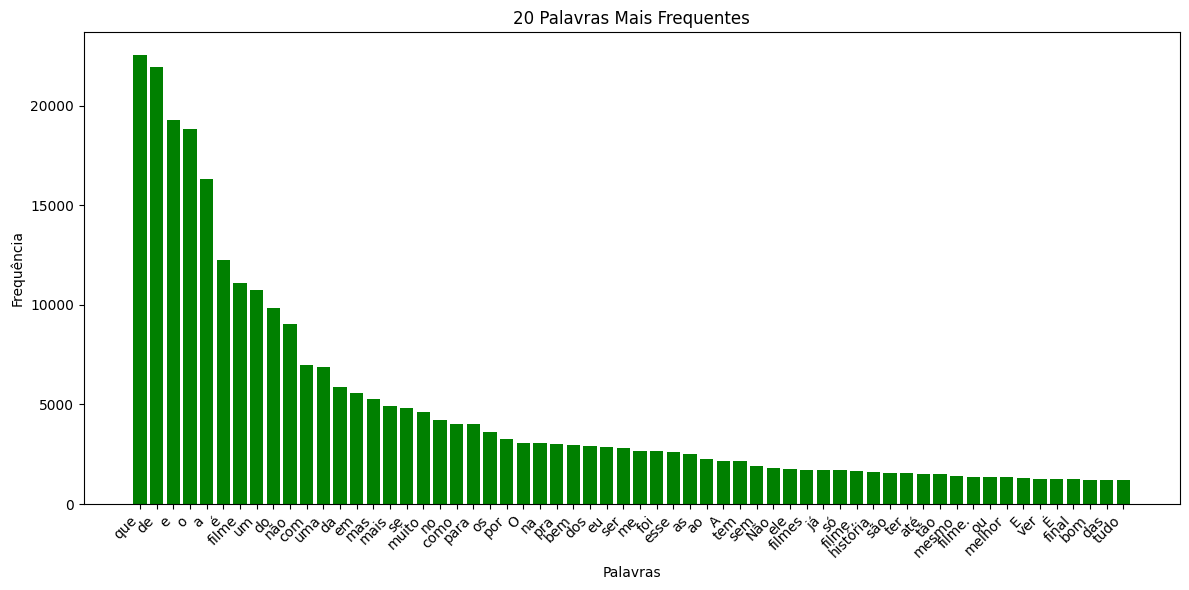

In [ ]:

import matplotlib.pyplot as plt

# Conta a frequência das palavras
word_counts = Counter(" ".join(dataset_movies['review_text']).split())

# Seleciona as 20 palavras mais frequentes
top_20_words = word_counts.most_common(60)

# Separa as palavras e as contagens
words = [word for word, count in top_20_words]
counts = [count for word, count in top_20_words]

# Cria o gráfico de barras
plt.figure(figsize=(12, 6))
plt.bar(words, counts, color='green')
plt.xlabel('Palavras')
plt.ylabel('Frequência')
plt.title('20 Palavras Mais Frequentes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
dataset_movies.unique(subset=['polarity'])

original_index,review_text,polarity,rating,polarity_label
i64,str,f64,i64,str
581336,"""Tédio define. …",0.0,2,"""negative"""
1542761,"""Uma comédia pa…",1.0,4,"""positive"""


In [ ]:
preprocessor_lemma = TextPreprocessor(stemming=False, custom_stopwords=custom_stopwords)
preprocessor_stem = TextPreprocessor(lemmatization=False, custom_stopwords=custom_stopwords)

/usr/local/lib/python3.10/dist-packages/spacy/util.py:1740: UserWarning: [W111] Jupyter notebook detected: if using `prefer_gpu()` or `require_gpu()`, include it in the same cell right before `spacy.load()` to ensure that the model is loaded on the correct device. More information: http://spacy.io/usage/v3#jupyter-notebook-gpu
  warnings.warn(Warnings.W111)


In [ ]:
preprocessor_lemma.fit_top_n_words(dataset_movies['review_text'].to_list())


In [ ]:
df_processed_lemma = preprocessor_lemma.transform(dataset_movies, "review_text")

<ipython-input-207-871e3b04cf5b>:68: DeprecationWarning: `apply` is deprecated. It has been renamed to `map_elements`.
  pl.col(text_column).apply(self.preprocess_text).alias(text_column + "_processed")


In [ ]:
df_processed_stem = preprocessor_stem.transform(dataset_movies, "review_text")

<ipython-input-207-871e3b04cf5b>:68: DeprecationWarning: `apply` is deprecated. It has been renamed to `map_elements`.
  pl.col(text_column).apply(self.preprocess_text).alias(text_column + "_processed")


In [ ]:
df_processed_lemma.head()

original_index,review_text,polarity,rating,polarity_label,review_text_processed
i64,str,f64,i64,str,list[str]
1542761,"""Uma comédia pa…",1.0,4,"""positive""","[""pouco""]"
1136476,"""Uma das melhor…",1.0,5,"""positive""","[""bom"", ""Burton"", … ""cruel""]"
473062,"""Muito massa! G…",1.0,5,"""positive""","[""massa"", ""gosto""]"
305951,"""O que falar de…",1.0,5,"""positive""","[""falar"", ""filme"", … ""certo""]"
1251806,"""Filme muito in…",1.0,4,"""positive""","[""filme"", ""inteligente"", … ""gostar""]"


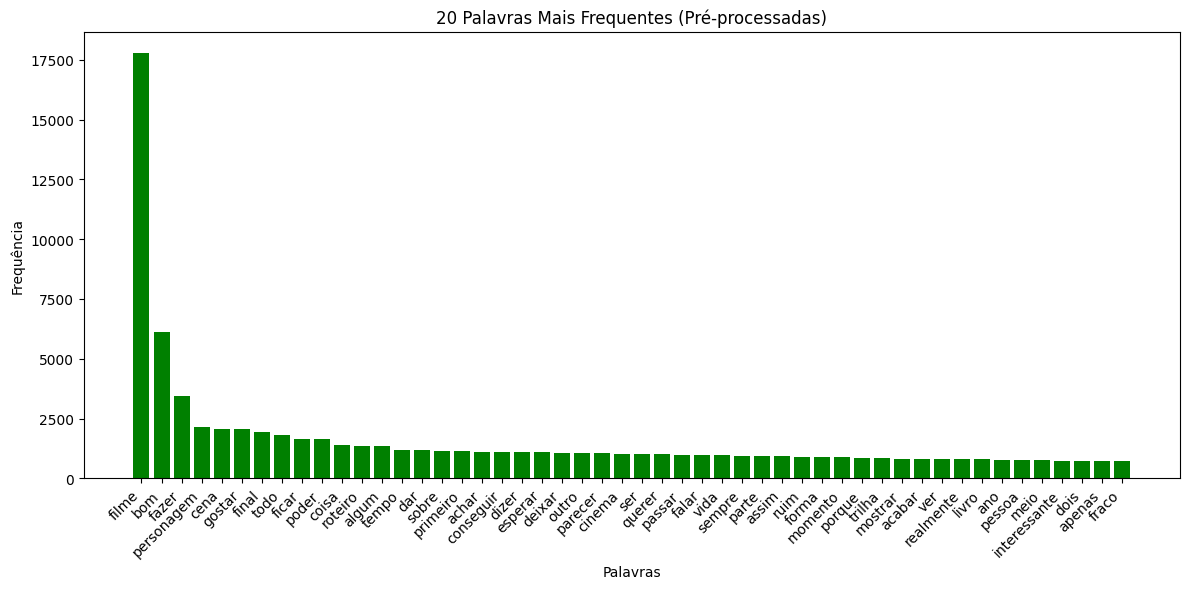

In [ ]:

# Conta a frequência das palavras
word_counts_processed = Counter(token for tokens in df_processed_lemma['review_text_processed'] for token in tokens)

# Seleciona as 20 palavras mais frequentes
top_20_words_processed = word_counts_processed.most_common(50)

# Separa as palavras e as contagens
words_processed = [word for word, count in top_20_words_processed]
counts_processed = [count for word, count in top_20_words_processed]

plt.figure(figsize=(12, 6))
plt.bar(words_processed, counts_processed, color='green')
plt.xlabel('Palavras')
plt.ylabel('Frequência')
plt.title('20 Palavras Mais Frequentes (Pré-processadas)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


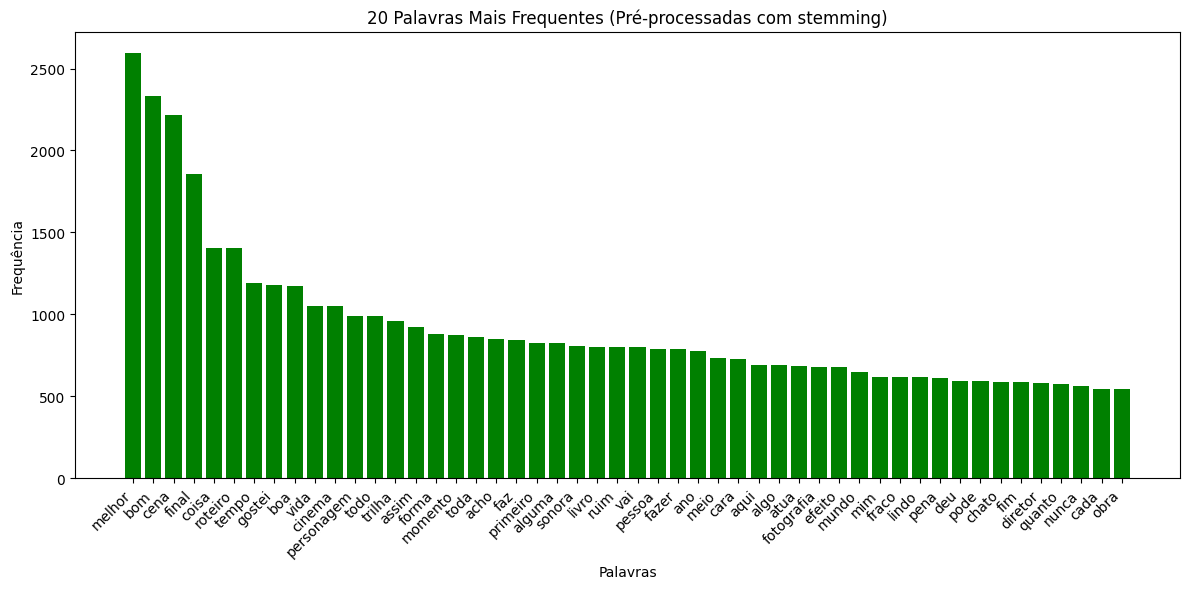

In [ ]:


word_counts_processed = Counter(token for tokens in df_processed_stem['review_text_processed'] for token in tokens)


top_20_words_processed = word_counts_processed.most_common(50)

words_processed = [word for word, count in top_20_words_processed]
counts_processed = [count for word, count in top_20_words_processed]

plt.figure(figsize=(12, 6))
plt.bar(words_processed, counts_processed, color='green')
plt.xlabel('Palavras')
plt.ylabel('Frequência')
plt.title('20 Palavras Mais Frequentes (Pré-processadas com stemming)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
df_tf_idf = tfidf_vectorizer(df_processed_lemma, 'review_text_processed')


<ipython-input-208-7872518b3869>:75: RuntimeWarning: invalid value encountered in divide
  tfidf_matrix = tfidf_matrix / row_norms


In [ ]:
df_count_vec = count_vectorizer(df_processed_lemma, 'review_text_processed')

In [ ]:
df_count_vec_stem = count_vectorizer(df_processed_stem, 'review_text_processed')

In [ ]:
df_count_vec.head()

original_index,review_text,polarity,rating,polarity_label,review_text_processed,term_vira,term_publico,term_aonde,term_erro,term_trunfo,term_sinceramente,term_olhe,term_lance,term_fuga,term_potencial,term_confuso,term_fizesse,term_pesada,term_estado,term_complicado,term_cura,term_carinha,term_raiva,term_Ford,term_atuar,term_procurar,term_seguir,term_leve,term_assustador,term_have,term_cedo,term_boa,term_amor,term_acaba,term_elevador,term_Leia,…,term_tirar,term_principalmente,term_entanto,term_animal,term_previsivel,term_falo,term_modelo,term_bobinha,term_good,term_ambos,term_diga,term_noite,term_cotidiano,term_cumpre,term_boca,term_dublagem,term_buraco,term_apartamento,term_moral,term_putz,term_tiro,term_Meio,term_Leonardo,term_consegui,term_briga,term_desenvolver,term_paz,term_apresenta,term_recente,term_demorar,term_rumo,term_terra,term_fico,term_convence,term_magia,term_chama,term_encantador
i64,str,f64,i64,str,list[str],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1542761,"""Uma comédia pa…",1.0,4,"""positive""","[""pouco""]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1136476,"""Uma das melhor…",1.0,5,"""positive""","[""bom"", ""Burton"", … ""cruel""]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
473062,"""Muito massa! G…",1.0,5,"""positive""","[""massa"", ""gosto""]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
305951,"""O que falar de…",1.0,5,"""positive""","[""falar"", ""filme"", … ""certo""]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1251806,"""Filme muito in…",1.0,4,"""positive""","[""filme"", ""inteligente"", … ""gostar""]",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,…,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 1º questão

* Usando a vetorização por TF-IDF com pré-processamento

In [ ]:
print("Resultados com TF-IDF com pré-processamento: \n ", results_tfidf)

Resultados com TF-IDF com pré-processamento: 
  {'Accuracy': '72.67%'}



Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.79      0.62      0.69      1981
           1       0.69      0.84      0.76      2019

    accuracy                           0.73      4000
   macro avg       0.74      0.73      0.72      4000
weighted avg       0.74      0.73      0.72      4000



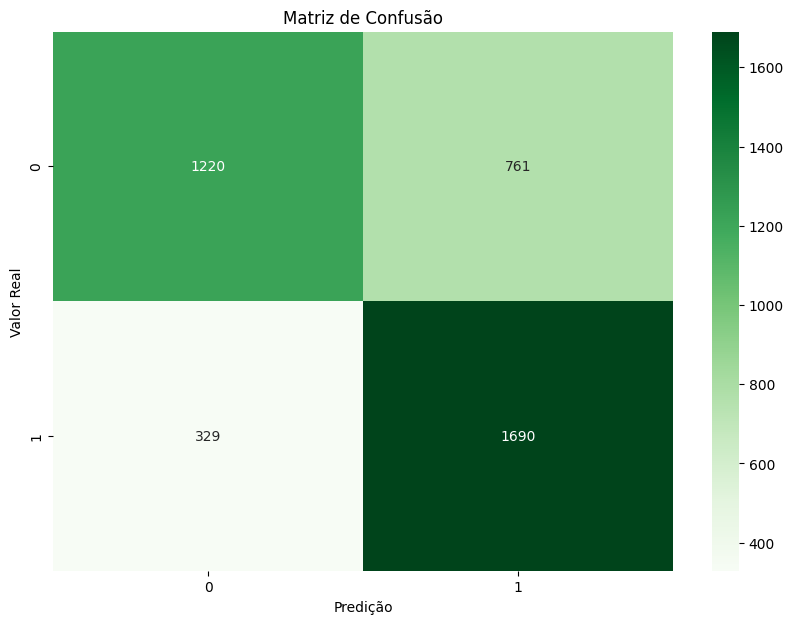

In [ ]:
results_tfidf = evaluate_model(df_tf_idf, "^tfidf_.*$")

* Usando a vetorização por TF-IDF sem-processamento

Acurácia: 0.776

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.80      0.72      0.76      1981
           1       0.75      0.83      0.79      2019

    accuracy                           0.78      4000
   macro avg       0.78      0.78      0.78      4000
weighted avg       0.78      0.78      0.78      4000



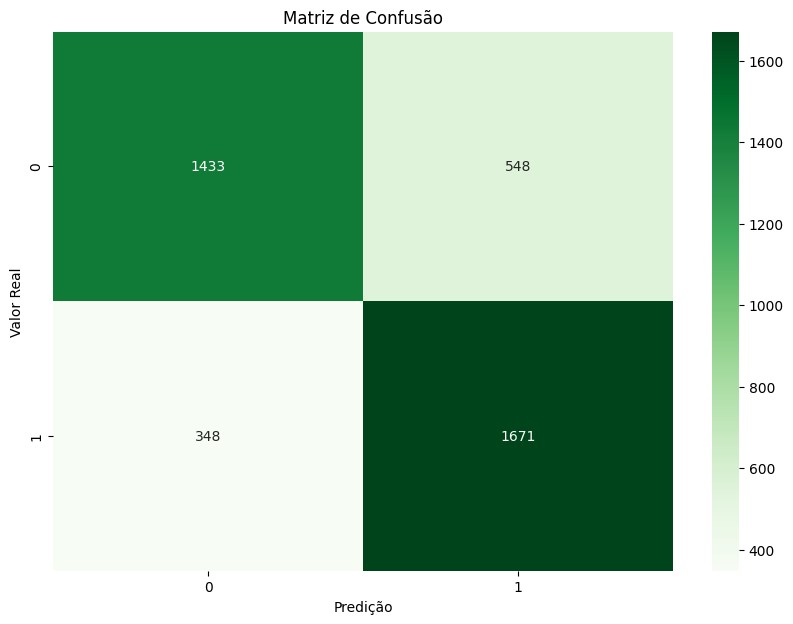

In [ ]:
# @title Texto de título padrão

X = df_tf_idf.select('review_text').to_pandas()


vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(X['review_text'])

y = df_tf_idf.select('polarity_label').to_series()


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBClassifier()

le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

model.fit(X_train, y_train_encoded)

y_pred = model.predict(X_test)

# Calcula a acurácia
accuracy = accuracy_score(y_test_encoded, y_pred)
print("Acurácia:", accuracy)

# Imprime o relatório de classificação
print("\nRelatório de Classificação:")
print(classification_report(y_test_encoded, y_pred))

# Calcula a matriz de confusão
cm = confusion_matrix(y_test_encoded, y_pred)

# Plota a matriz de confusão
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predição')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusão')
plt.show()

## 2º questão

In [ ]:
print("Resultados com CountVectorizer com pré-processamento: \n ", results_count_vec)

Resultados com CountVectorizer com pré-processamento: 
  {'Accuracy': '73.40%'}



Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.79      0.61      0.69      1981
           1       0.69      0.84      0.76      2019

    accuracy                           0.73      4000
   macro avg       0.74      0.72      0.72      4000
weighted avg       0.74      0.73      0.72      4000



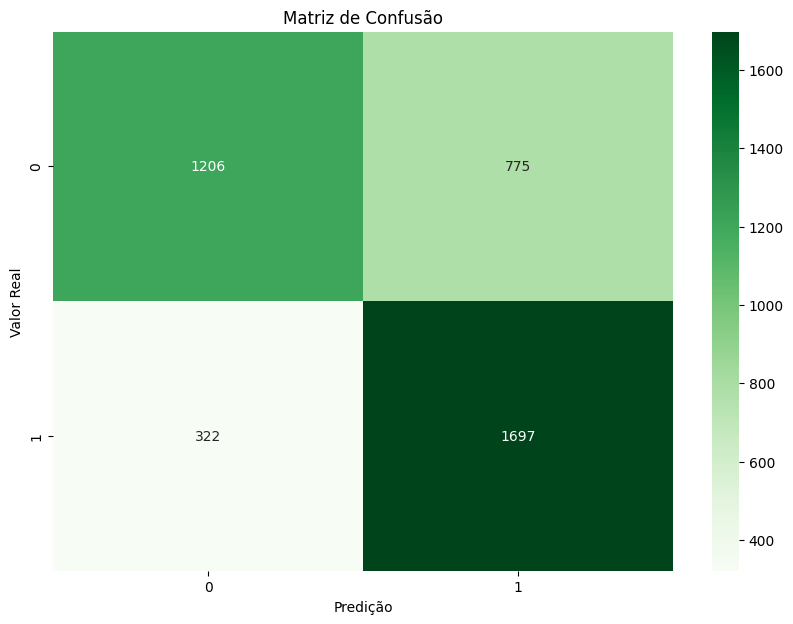

In [ ]:
results_count_vec = evaluate_model(df_count_vec, "^term_.*$")

## 3º questão

* Pré processamento com steamming e vetorização utilizando Count Vectorize

In [ ]:
print("Resultados CountVectorizer com pré-processamento: \n ", results_count_vec_stem)

Resultados CountVectorizer com pré-processamento: 
  {'Accuracy': '73.50%'}



Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.80      0.61      0.69      1981
           1       0.69      0.85      0.76      2019

    accuracy                           0.73      4000
   macro avg       0.74      0.73      0.73      4000
weighted avg       0.74      0.73      0.73      4000



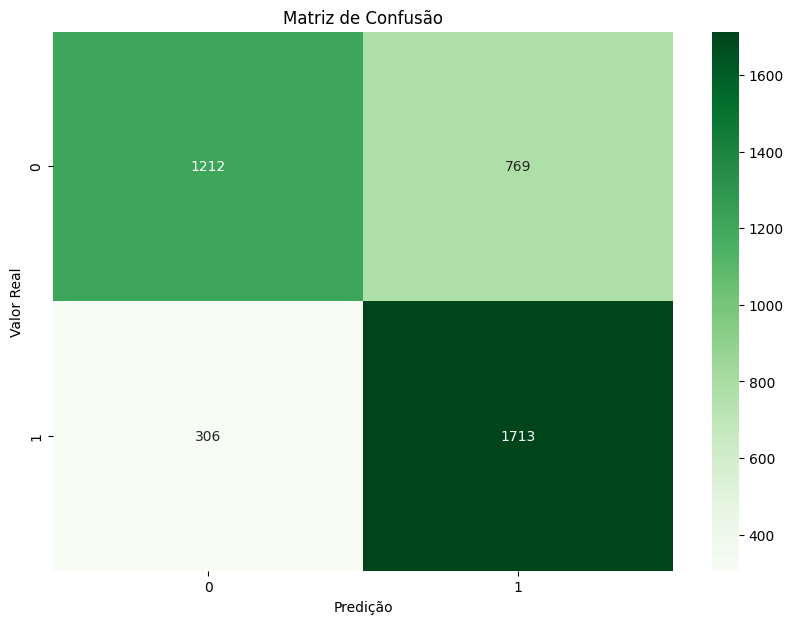

In [ ]:
results_count_vec_stem = evaluate_model(df_count_vec_stem, "^term_.*$")